<center>
<h1> Car Price Prediction</h1>
</center>

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
%matplotlib inline

In [2]:
#Loading dataset
df = pd.read_csv(r'Car prices.csv')
df.head()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
1,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13 km/kg,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
2,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
3,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
4,6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,3.50


In [3]:
#since there is one unnammed column which is nothing but index
#droping the index column
df = df.iloc[:,1:]
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
1,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13 km/kg,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
2,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
3,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
4,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,3.50


In [4]:
print(f'No. of rows: {df.shape[0]}')
print(f'No. of columns: {df.shape[1]}')

No. of rows: 5847
No. of columns: 13


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5847 entries, 0 to 5846
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               5847 non-null   object 
 1   Location           5847 non-null   object 
 2   Year               5847 non-null   int64  
 3   Kilometers_Driven  5847 non-null   int64  
 4   Fuel_Type          5847 non-null   object 
 5   Transmission       5847 non-null   object 
 6   Owner_Type         5847 non-null   object 
 7   Mileage            5845 non-null   object 
 8   Engine             5811 non-null   object 
 9   Power              5811 non-null   object 
 10  Seats              5809 non-null   float64
 11  New_Price          815 non-null    object 
 12  Price              5847 non-null   float64
dtypes: float64(2), int64(2), object(9)
memory usage: 594.0+ KB


In [6]:
df.isna().sum()

Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 36
Power                  36
Seats                  38
New_Price            5032
Price                   0
dtype: int64

In [7]:
df.isna().sum()/len(df)*100

Name                  0.000000
Location              0.000000
Year                  0.000000
Kilometers_Driven     0.000000
Fuel_Type             0.000000
Transmission          0.000000
Owner_Type            0.000000
Mileage               0.034206
Engine                0.615700
Power                 0.615700
Seats                 0.649906
New_Price            86.061228
Price                 0.000000
dtype: float64

*since 'Mileage', 'Engine', 'Power', 'Seats' have less than 0.6% of missing values, we can safely drop these rows*

In [8]:
df.columns

Index(['Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats',
       'New_Price', 'Price'],
      dtype='object')

In [9]:
#dropping null values with less than 0.6% missing values
df.dropna(subset = ['Mileage','Engine','Power','Seats'],inplace = True)

In [10]:
df.isna().sum()

Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 0
Engine                  0
Power                   0
Seats                   0
New_Price            4993
Price                   0
dtype: int64

In [11]:
#since New_Price column has more than 80% of missing values, we can drop it
df.drop('New_Price', axis = 1, inplace = True)

In [12]:
df.isna().sum()

Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64

In [13]:
df.dtypes

Name                  object
Location              object
Year                   int64
Kilometers_Driven      int64
Fuel_Type             object
Transmission          object
Owner_Type            object
Mileage               object
Engine                object
Power                 object
Seats                float64
Price                float64
dtype: object

In [14]:
df['Mileage'].unique()

array(['19.67 kmpl', '13 km/kg', '20.77 kmpl', '15.2 kmpl', '23.08 kmpl',
       '11.36 kmpl', '20.54 kmpl', '22.3 kmpl', '21.56 kmpl', '16.8 kmpl',
       '25.2 kmpl', '12.7 kmpl', '0.0 kmpl', '13.5 kmpl', '25.8 kmpl',
       '28.4 kmpl', '20.45 kmpl', '14.84 kmpl', '22.69 kmpl',
       '23.65 kmpl', '13.53 kmpl', '18.5 kmpl', '14.4 kmpl',
       '16.48 km/kg', '20.92 kmpl', '17.5 kmpl', '12.8 kmpl',
       '19.01 kmpl', '14.53 kmpl', '11.18 kmpl', '12.4 kmpl',
       '16.09 kmpl', '14.0 kmpl', '24.3 kmpl', '18.15 kmpl', '11.74 kmpl',
       '22.07 kmpl', '19.7 kmpl', '25.4 kmpl', '25.32 kmpl', '14.62 kmpl',
       '14.28 kmpl', '14.9 kmpl', '11.25 kmpl', '24.4 kmpl', '16.55 kmpl',
       '17.11 kmpl', '22.9 kmpl', '17.8 kmpl', '18.9 kmpl', '15.04 kmpl',
       '25.17 kmpl', '20.36 kmpl', '9.49 km/kg', '18.2 kmpl',
       '13.68 kmpl', '20.0 kmpl', '15.8 kmpl', '25.0 kmpl', '16.4 kmpl',
       '24.52 kmpl', '22.1 kmpl', '8.5 kmpl', '15.1 kmpl', '16.95 kmpl',
       '19.64 kmpl', '16.5

we need to extract the number from milage column

In [15]:
#removing text from milage column
df['Mileage'] = df['Mileage'].str.extract(r'([\d.]+)')

In [16]:
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582 CC,126.2 bhp,5.0,12.50
1,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13,1199 CC,88.7 bhp,5.0,4.50
2,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248 CC,88.76 bhp,7.0,6.00
3,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2,1968 CC,140.8 bhp,5.0,17.74
4,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08,1461 CC,63.1 bhp,5.0,3.50


In [17]:
df['Mileage'] = df['Mileage'].astype('float')

In [18]:
df.dtypes

Name                  object
Location              object
Year                   int64
Kilometers_Driven      int64
Fuel_Type             object
Transmission          object
Owner_Type            object
Mileage              float64
Engine                object
Power                 object
Seats                float64
Price                float64
dtype: object

Removing texts from power and engine column

In [19]:
df['Power'] = df['Power'].str.extract(r'([\d.]+)').astype('float')
df['Engine'] = df['Engine'].str.extract(r'([\d.]+)').astype('float')

In [20]:
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50
1,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13.00,1199.0,88.70,5.0,4.50
2,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00
3,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74
4,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08,1461.0,63.10,5.0,3.50


In [21]:
df['Price'].unique()

array([12.5 ,  4.5 ,  6.  , ..., 30.54, 17.56,  7.43])

# Feature engineering, Car Age

In [22]:
from datetime import datetime 
df['car_age'] = 2021 - df['Year']

In [23]:
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,car_age
0,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50,6
1,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13.00,1199.0,88.70,5.0,4.50,10
2,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00,9
3,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74,8
4,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08,1461.0,63.10,5.0,3.50,8


In [24]:
#dropping year column since we have age column
df.drop(columns = ['Year'], axis = 1, inplace = True)

In [25]:
df.dtypes

Name                  object
Location              object
Kilometers_Driven      int64
Fuel_Type             object
Transmission          object
Owner_Type            object
Mileage              float64
Engine               float64
Power                float64
Seats                float64
Price                float64
car_age                int64
dtype: object

In [26]:
#extracting brand name
df['Brand'] = df['Name'].str.split().str[0]
df.drop(columns = ['Name'], axis = 1, inplace = True)

In [27]:
df.sample(5)

,Location,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,car_age,Brand
4810,Jaipur,100000,Petrol,Manual,First,19.70,796.0,46.30,5.0,1.50,10,Maruti
3981,Kochi,65178,Diesel,Manual,First,19.87,1461.0,83.80,5.0,6.79,6,Renault
4208,Bangalore,52000,Petrol,Manual,First,18.50,1197.0,80.00,5.0,3.65,11,Hyundai
1023,Pune,90000,Diesel,Manual,First,19.01,1461.0,108.45,5.0,7.25,7,Renault
1998,Kolkata,65000,Diesel,Manual,Second,13.60,1991.0,142.00,5.0,4.90,12,Hyundai


In [28]:
columns = ['Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']

In [29]:
for i in columns:
    print(df[i].nlargest(5))
    print(df[i].nsmallest(5))
    print()

2259    6500000
326      775000
1805     720000
344      620000
2734     480000
Name: Kilometers_Driven, dtype: int64
1315     171
5451     600
165     1000
1123    1000
1160    1000
Name: Kilometers_Driven, dtype: int64

15     28.4
51     28.4
264    28.4
851    28.4
864    28.4
Name: Mileage, dtype: float64
12     0.0
65     0.0
524    0.0
683    0.0
929    0.0
Name: Mileage, dtype: float64

5368    5998.0
144     5461.0
4556    5461.0
4585    5461.0
5620    5204.0
Name: Engine, dtype: float64
39     624.0
107    624.0
118    624.0
503    624.0
715    624.0
Name: Engine, dtype: float64

5620    560.0
5368    552.0
2040    550.0
4942    503.0
68      500.0
Name: Power, dtype: float64
764     34.2
974     34.2
1856    34.2
2133    34.2
2760    34.2
Name: Power, dtype: float64

788     10.0
887     10.0
1852    10.0
2492    10.0
1302     9.0
Name: Seats, dtype: float64
127     2.0
537     2.0
669     2.0
772     2.0
1043    2.0
Name: Seats, dtype: float64

3952    160.00
5620    120.00

by the above values we can notice that milage has 0 values, which is an error or mising value

In [30]:
#Number of 0 values
(df['Mileage'] == 0).sum()

28

In [31]:
#filling 0 values with null
df.loc[df['Mileage'] == 0, 'Mileage']= np.nan

In [32]:
#filling 0 values with median
df['Mileage'] = df.groupby('Fuel_Type')['Mileage'].transform(lambda x: x.fillna(x.median()))

# Checking for outliers

Text(0.5, 1.0, 'Prices outliers')

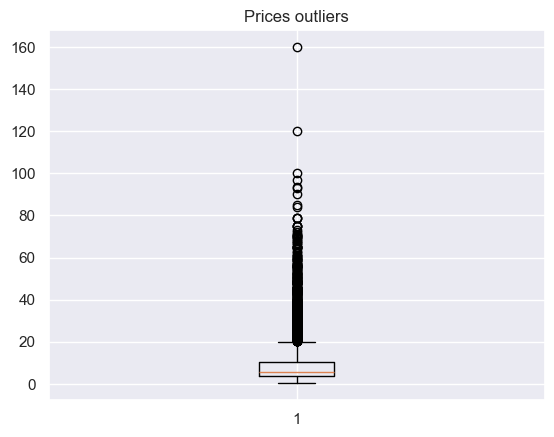

In [33]:
plt.boxplot(df['Price'])
plt.title('Prices outliers')

In [34]:
# Function to get outlier rows
def get_outlier_rows(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers


price_outliers = get_outlier_rows(df, 'Price')
price_outliers


,Location,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,car_age,Brand
11,Delhi,72000,Diesel,Automatic,First,12.70,2179.0,187.70,5.0,27.00,7,Land
17,Bangalore,78500,Diesel,Automatic,First,14.84,2143.0,167.62,5.0,28.00,7,Mercedes-Benz
20,Mumbai,55985,Petrol,Automatic,First,13.53,1984.0,177.01,5.0,23.50,6,Audi
36,Pune,85000,Diesel,Automatic,First,11.74,2987.0,254.80,5.0,28.00,8,Mercedes-Benz
48,Kochi,13648,Diesel,Automatic,First,17.11,1968.0,174.33,5.0,21.43,6,Audi
...,...,...,...,...,...,...,...,...,...,...,...,...
5776,Bangalore,16000,Diesel,Automatic,First,14.69,2993.0,258.00,5.0,48.00,5,BMW
5780,Bangalore,65630,Diesel,Automatic,First,15.73,1968.0,174.33,5.0,21.75,7,Audi
5800,Kochi,17773,Petrol,Automatic,First,13.70,1991.0,183.00,5.0,26.76,3,Mercedes-Benz
5825,Kochi,31150,Diesel,Automatic,First,16.36,2179.0,187.70,5.0,30.54,5,Jaguar


In [35]:
df['Brand'].value_counts()

Brand
Maruti           1121
Hyundai          1050
Honda             600
Toyota            393
Mercedes-Benz     316
Volkswagen        314
Ford              294
Mahindra          268
BMW               262
Audi              235
Tata              181
Skoda             172
Renault           145
Chevrolet         120
Nissan             89
Land               57
Jaguar             40
Mitsubishi         27
Mini               26
Fiat               23
Volvo              21
Porsche            16
Jeep               15
Datsun             13
Force               3
ISUZU               2
Ambassador          1
Isuzu               1
Bentley             1
Lamborghini         1
Name: count, dtype: int64

**By the above analysis we can notice that bottom 5 of the cars are least in numbers which is also the cause of outlier along with luxurious cars, but these expensive cars are real data not outliers, so its better to keep them**

In [36]:
df['Brand'] = df['Brand'].replace('ISUZU','Isuzu')
df['Brand'] = df['Brand'].replace('Land','Land Rover')
df['Brand'] = df['Brand'].replace('Ambassador','Hindustan')


In [37]:
df['Brand'].value_counts()

Brand
Maruti           1121
Hyundai          1050
Honda             600
Toyota            393
Mercedes-Benz     316
Volkswagen        314
Ford              294
Mahindra          268
BMW               262
Audi              235
Tata              181
Skoda             172
Renault           145
Chevrolet         120
Nissan             89
Land Rover         57
Jaguar             40
Mitsubishi         27
Mini               26
Fiat               23
Volvo              21
Porsche            16
Jeep               15
Datsun             13
Isuzu               3
Force               3
Hindustan           1
Bentley             1
Lamborghini         1
Name: count, dtype: int64

In [38]:
num_cols = df.select_dtypes(include=['int64','float64'])
corr_matrix = num_cols.corr()

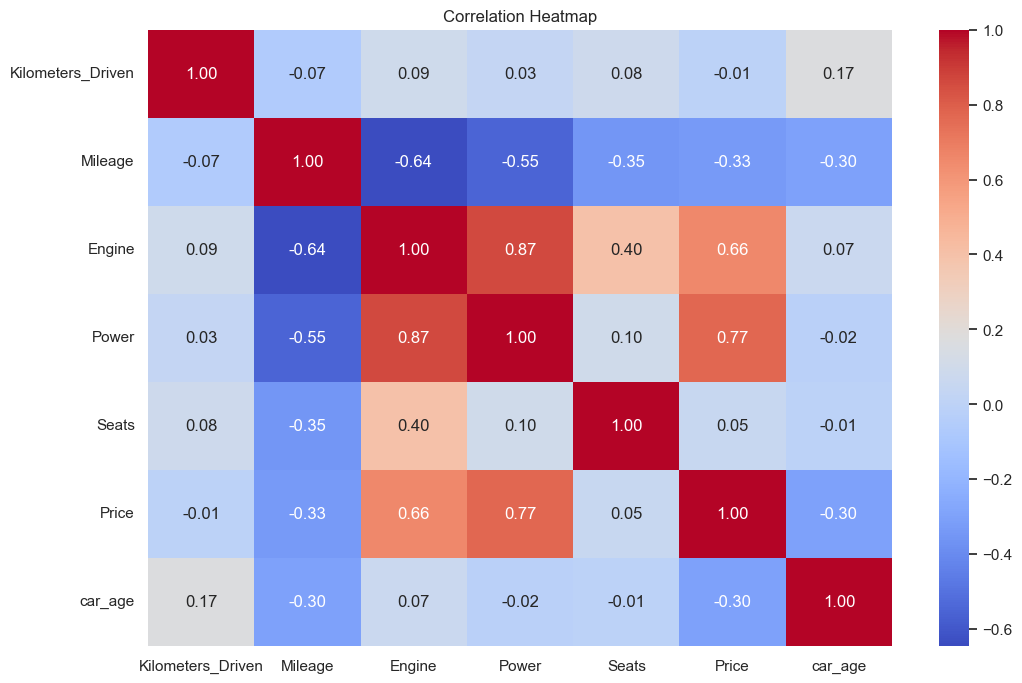

In [39]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Since engine and power is co-related with eachother, we will drop power, keeping in mind user awareness while using the predictor app**

In [40]:
df.drop(columns = ['Power'], axis=1, inplace = True)

In [41]:
df.head()

,Location,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Price,car_age,Brand
0,Pune,41000,Diesel,Manual,First,19.67,1582.0,5.0,12.50,6,Hyundai
1,Chennai,46000,Petrol,Manual,First,13.00,1199.0,5.0,4.50,10,Honda
2,Chennai,87000,Diesel,Manual,First,20.77,1248.0,7.0,6.00,9,Maruti
3,Coimbatore,40670,Diesel,Automatic,Second,15.20,1968.0,5.0,17.74,8,Audi
4,Jaipur,86999,Diesel,Manual,First,23.08,1461.0,5.0,3.50,8,Nissan


In [42]:
df.head()

,Location,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Price,car_age,Brand
0,Pune,41000,Diesel,Manual,First,19.67,1582.0,5.0,12.50,6,Hyundai
1,Chennai,46000,Petrol,Manual,First,13.00,1199.0,5.0,4.50,10,Honda
2,Chennai,87000,Diesel,Manual,First,20.77,1248.0,7.0,6.00,9,Maruti
3,Coimbatore,40670,Diesel,Automatic,Second,15.20,1968.0,5.0,17.74,8,Audi
4,Jaipur,86999,Diesel,Manual,First,23.08,1461.0,5.0,3.50,8,Nissan


In [43]:
df.groupby('Location')['Price'].mean().sort_values(ascending=False)


Location
Coimbatore    15.140350
Bangalore     13.638040
Kochi         11.323940
Hyderabad     10.003343
Delhi          9.905514
Mumbai         9.566592
Ahmedabad      8.593134
Chennai        7.960802
Pune           6.992324
Jaipur         5.949225
Kolkata        5.739885
Name: Price, dtype: float64

In [44]:
df['Location'].nunique()

11

In [45]:
df2 = df

In [46]:
df2['Location'].value_counts()

Location
Mumbai        757
Hyderabad     709
Kochi         637
Coimbatore    629
Pune          581
Delhi         535
Kolkata       521
Chennai       474
Jaipur        400
Bangalore     347
Ahmedabad     217
Name: count, dtype: int64

**We will drop the location column, since the car prices sont completly depend on the location**

In [47]:
df2.drop(columns = ['Location'], axis = 1, inplace = True)

In [48]:
df2.head()

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Price,car_age,Brand
0,41000,Diesel,Manual,First,19.67,1582.0,5.0,12.50,6,Hyundai
1,46000,Petrol,Manual,First,13.00,1199.0,5.0,4.50,10,Honda
2,87000,Diesel,Manual,First,20.77,1248.0,7.0,6.00,9,Maruti
3,40670,Diesel,Automatic,Second,15.20,1968.0,5.0,17.74,8,Audi
4,86999,Diesel,Manual,First,23.08,1461.0,5.0,3.50,8,Nissan


# Encode categorical columns

In [49]:
cat_col = ['Brand', 'Fuel_Type', 'Transmission', 'Owner_Type']


In [50]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in cat_col:
    le = LabelEncoder()
    df2[col] = le.fit_transform(df2[col])
    label_encoders[col] = le

In [51]:
df.head()

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Price,car_age,Brand
0,41000,0,1,0,19.67,1582.0,5.0,12.50,6,10
1,46000,1,1,0,13.00,1199.0,5.0,4.50,10,9
2,87000,0,1,0,20.77,1248.0,7.0,6.00,9,17
3,40670,0,0,2,15.20,1968.0,5.0,17.74,8,0
4,86999,0,1,0,23.08,1461.0,5.0,3.50,8,21


# Standardization

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df2.drop('Price', axis=1)
y = df2['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_cols = ['Kilometers_Driven', 'Mileage', 'Engine', 'Seats', 'car_age']

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


# Linear Regression

In [53]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [54]:
y_pred = lr_model.predict(X_test)

In [55]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score :", r2)
print("MAE      :", mae)
print("RMSE     :", rmse)

R2 Score : 0.6323966688965321
MAE      : 4.13682520402104
RMSE     : 6.445871221300005


**Moderate results, not that great, we will try other models**

# Random Forest

In [56]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Initialize
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,       
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest - R2:", r2)
print("Random Forest - MAE:", mae)
print("Random Forest - RMSE:", rmse)

Random Forest - R2: 0.8271444971084339
Random Forest - MAE: 1.848607376497201
Random Forest - RMSE: 4.420114408614335


# Gradient Boosting Regressor

In [57]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=3,
    subsample=0.8,
    max_features='sqrt',
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred_gb)
mae = mean_absolute_error(y_test, y_pred_gb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print("Gradient Boosting - R2:", r2)
print("Gradient Boosting - MAE:", mae)
print("Gradient Boosting - RMSE:", rmse)

Gradient Boosting - R2: 0.8730153690507134
Gradient Boosting - MAE: 1.7293049990071643
Gradient Boosting - RMSE: 3.7885016976960095


# XG Boost

In [58]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    objective='reg:squarederror'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred_xgb)
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost - R2:", r2)
print("XGBoost - MAE:", mae)
print("XGBoost - RMSE:", rmse)

XGBoost - R2: 0.8366936709024676
XGBoost - MAE: 1.7369487944086324
XGBoost - RMSE: 4.296288271970302


# Cross Validation

In [59]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [300, 500],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
}

grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best params:", grid_search.best_params_)


Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.8}


**By the above models and results we can conclude that Gradient Boost performs better, and it will be our final model**

In [60]:
feature_order = X.columns.tolist()

In [62]:
import pickle

final_bundle = {
    "model": gb_model,
    "scaler": scaler,
    "encoder": label_encoders,
    "num_cols": num_cols,
    "cat_cols": cat_col,
    "feature_order": feature_order   # ✅ VERY IMPORTANT
}

with open("car_price_pipeline.pkl", "wb") as file:
    pickle.dump(final_bundle, file)


In [63]:
import sys, sklearn
print(sys.version)
print(sklearn.__version__)


3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]
1.3.2


In [ ]:
pip show scikit-learn